# Benchmark: PXD014777 HeLa 10 replicate dataset

Let's start with the imports.

In [1]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import pipp
import pipp.utils

np.random.seed(0)

Let's define the paths to the data and the pretrained model.

In [2]:
PRETRAINED_MODEL_PATH = "../../checkpoints/PXD019086_PXD010012_combined_evidence_90Kto20Ksplit_5query_1shot_fullmodel_featuresScaled_allPeptidesTxtFeatures_modSeqSpecies_hidden64_latent10_maxEpoch300_164trainways_xlatent_conditionalEmbedding.pth"

HELA_MS1_OUT_PATH = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MS2_OUT_PATH = "../../data/PXD014777/processed/hela_ms2.csv"
SPECIES_MS2_OUT_PATH = "../../data/PXD014777/processed/species_ms2.csv"

In [3]:
df_ms1_hela = pd.read_csv(HELA_MS1_OUT_PATH)
df_ms2_hela = pd.read_csv(HELA_MS2_OUT_PATH)
df_ms2_species = pd.read_csv(SPECIES_MS2_OUT_PATH)

/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_72861/1735780731.py:2: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ms2_hela = pd.read_csv(HELA_MS2_OUT_PATH)
/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_72861/1735780731.py:3: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ms2_species = pd.read_csv(SPECIES_MS2_OUT_PATH)


## PIPP model

### Computing the Embeddings

Let's load the model and compute the embeddings.

In [ ]:
features = [
    "Charge",
    "Mass",
    "m/z",
    "Retention time",
    "Retention length",
    "Ion mobility index",
    "Ion mobility length",
    "Number of isotopic peaks",
]

In [5]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [6]:
ms1_embeddings = model.get_latent_representations(df_ms1_hela[features])

In [7]:
ms2_embeddings = model.get_latent_representations(df_ms2_hela[features])

In [8]:
ms1_embeddings = ms1_embeddings - np.mean(ms1_embeddings, axis=0)
ms2_embeddings = ms2_embeddings - np.mean(ms2_embeddings, axis=0)

Let's look at the embedding space.
We'll look at a subset of peptides due to memory limitations.

In [9]:
n = 50_000
random_indices = np.random.choice(range(len(ms2_embeddings)), size=n, replace=False)

Let's also add some "random" peptides to ensure all possible runs of at least a few peptides are included.

In [10]:
high_coverage_peptides_to_include = [
    '_(ac)AAAAAAAAAAGAAGGR_2',
    '_LGMENDDTAVQYAIGR_2',
    '_LGHVVMGNNAVSPYQQVIEK_2',
    '_LEEVLSTEGAEENGNSDK_2',
    '_PAPQMNGSTGDAR_2',
    '_HLQINQTFEELR_2',
    '_LLAGEDGTSER_2',
    '_LETMPLYLEDDIRPDIK_3',
    '_LFNDSSPVVLEESWDALNAITK_3',
]

low_coverage_peptides_to_include = [
    '_ELFEQYGAVYEINVLR_3',
    '_ELFDELVK_2',
    '_FLGDYVENLNK_2',
    '_HHSQQAPQAEAPCLLR_3',
    '_HFSTTTNNIQSR_2',
    '_LEEIAELVASSLPSPLR_3',
    '_AVLEQFGFPLTGTEAR_2',
    '_VPQFSFLDIFPK_2',
    '_VGPYHNPQETYHYYQLPVCCPEK_3',
    '_FDSASSSYYLDMHSLPHVINPVESR_4',
]

peptides_to_include = high_coverage_peptides_to_include + low_coverage_peptides_to_include

custom_indices = [df_ms2_hela.index[df_ms2_hela['PrecursorID'] == peptide].tolist() for peptide in peptides_to_include]
custom_indices = [peptide for peptide_runs in custom_indices for peptide in peptide_runs]
custom_indices = [df_ms2_hela.index.get_loc(i) for i in custom_indices]

# print(peptides_abundances)

In [11]:
indices = np.unique(np.concatenate((random_indices, custom_indices)))

In [12]:
df_ms2_hela_subset = df_ms2_hela.iloc[indices]
ms2_embeddings_subset = ms2_embeddings[indices]

Let's compute the UMAP for plotting.

In [13]:
# reducer = umap.UMAP(metric = 'cosine')
# umap_embedding = reducer.fit_transform(ms2_embeddings_subset)

In [14]:
'''fig, axs = plt.subplots(figsize=(14, 12), ncols=2, nrows=2)

ax = axs[0][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Retention time'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - RT')
fig.colorbar(sp)

ax = axs[0][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Charge'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Charge')
fig.colorbar(sp)

ax = axs[1][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Mass'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Mass')
fig.colorbar(sp)

ax = axs[1][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['m/z'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - m/z')
fig.colorbar(sp)
'''

"fig, axs = plt.subplots(figsize=(14, 12), ncols=2, nrows=2)\n\nax = axs[0][0]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Retention time'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - RT')\nfig.colorbar(sp)\n\nax = axs[0][1]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Charge'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - Charge')\nfig.colorbar(sp)\n\nax = axs[1][0]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['Mass'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - Mass')\nfig.colorbar(sp)\n\nax = axs[1][1]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=df_ms2_hela_subset['m/z'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - m/z')\nfig.colorbar(sp)\n"

Let's also plot the latent space of the MS2 data together with some low coverage and high coverage peptides.

In [15]:
'''
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
fig.tight_layout(pad=4.0)

# high coverage peptides
ax = axs[0]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(high_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_ms2_hela_subset['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - high coverage peptides')

# low coverage peptides
ax = axs[1]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(low_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_ms2_hela_subset['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - low coverage peptides')
'''

'\nfig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)\nfig.tight_layout(pad=4.0)\n\n# high coverage peptides\nax = axs[0]\nax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color=\'lightgrey\')\n\nfor i, peptide in enumerate(high_coverage_peptides_to_include):\n    peptide_ref_indices = np.where(df_ms2_hela_subset[\'PrecursorID\'] == peptide)\n    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")\n\nax.legend(markerscale=3, loc=\'upper center\', bbox_to_anchor=(0.5, -0.1))\nax.set_xlabel(\'UMAP1\')\nax.set_ylabel(\'UMAP2\')\nax.set_title(\'MS2 | latent space - high coverage peptides\')\n\n# low coverage peptides\nax = axs[1]\nax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color=\'lightgrey\')\n\nfor i, peptide in enumerate(low_coverage_peptides_to_include):\n    peptide_ref_indices = np.where(df_ms2_hela_subset[\'PrecursorID\'

## Peptide Identity Propagation

### Identification on the MS1 data

In [16]:
ms1_only_locs = df_ms1_hela.index.difference(df_ms2_hela.index)
ms1_only_ilocs = df_ms1_hela.index.get_indexer(ms1_only_locs)

In [17]:
ms1_only = df_ms1_hela.iloc[ms1_only_ilocs]

In [18]:
'''Specifies how many closest neighbours are computed for each query precursor.
Would it be sufficient to always choose 1?'''
k_neighbours = 15

'''
Specifies the ESM-2 model. The following models are available and are downloaded in the first use. 
    - "esm2_t6_8M_UR50D": 6 layers, 8 million parameters, 320-dim embedding
    - "esm2_t12_35M_UR50D": 12 layers, 35 million parameters, 480-dim embedding
    - "esm2_t30_150M_UR50D": 30 layers, 150 million parameters, 640-dim embedding
    - "esm2_t33_650M_UR50D": 33 layers, 650 million parameters, 1280-dim embedding
    - "esm2_t36_3B_UR50D": : 36 layers, 3 billion parameters, 2560-dim embedding, 6GB size
    - "esm2_t48_15B_UR50D": 48 layers, 15 billion parameters, 5120-dim embedding, 30GB size
In the model names, the number after the "t" stands for the total layer number.
The next number stands for the parameter number.
"UR50D" stands for the used training dataset of the ESM-2 model which is UniRef 50.
'''
esm2_model = "esm2_t6_8M_UR50D"

'''Specifies the ESM-2 layer from which the representations should be taken'''
n_representation_layer = 6

'''Specifies whether to use ESM-2 embeddings that have already been computed.
If True, then the location needs to be specified below.'''
use_precomputed_esm_embeddings = True

'''Specifies the relative path to the precomputed ESM-2 embeddings'''
esm_embedding_path = f'example_data/embeddings_{esm2_model}_layer{n_representation_layer}_datasetHeLa.npy'

'''Specifies whether to compute visualizations of the process'''
generate_visualizations = False

'''Specifies the numbers of anchors for the relative representation.
 For each entry in the list, a whole propagation run will be performed.'''
n_anchor_list = [5] # 5, 10, 50, 100, 200, 300, 400, 700, 1000

'''Specifies the numbers of principal components that the ESM-2 embedding ist reduced to.
 For each entry in the list, a whole propagation run will be performed.'''
n_pc_list = [2] # 1, 2, 3, 5, 10, 15, 20, 30, 40, 50

conduct_neighbour_experiment = False

'''Number of times the propagation function will be run.'''
number_of_test_runs = 1

results_df = pd.DataFrame(columns=['n_anchors',
                                   'n_pcs',
                                   'prop_nan_before',
                                   'prop_nan_after',
                                   'average_cv'])

for x in range(number_of_test_runs):
    
    for n_anchor in n_anchor_list:
        
        random_state = np.random.RandomState()
        anchors_idx = random_state.choice(60543, n_anchor, replace=False)
        
        for n_pc in n_pc_list:
            if n_pc == 0:
                use_concatenated_embeddings = False
            else:
                use_concatenated_embeddings = True
            
            print('Anchors: ', n_anchor, ', PCs: ', n_pc)
            identifications, confidence = model.propagate(
                ms1_only,
                df_ms2_hela,
                k_neighbours=k_neighbours,
                use_anchors=True,
                esm2_model=esm2_model,
                n_representation_layer=n_representation_layer,
                n_anchors=n_anchor,
                n_principal_components=n_pc,
                use_precomputed_esm_embeddings=use_precomputed_esm_embeddings,
                esm_embedding_path=esm_embedding_path,
                generate_visualizations=generate_visualizations,conduct_neighbour_experiment=conduct_neighbour_experiment,
                use_preselected_anchors=True,
                anchors_idx=anchors_idx,
                use_concatenated_embeddings=use_concatenated_embeddings,
                dataset="HeLa")
            
            ms1_expression_features = {
                'Raw file': ms1_only['Raw file'],
                'Intensities': ms1_only['Intensity'],
                'PrecursorID': identifications,
                'Confidence': confidence,
            }
            
            ms2_expression_features = {
                'Raw file': df_ms2_hela['Raw file'],
                'Intensities': df_ms2_hela['Intensity'],
                'PrecursorID': df_ms2_hela['PrecursorID'],
                'Confidence': np.ones(df_ms2_hela.shape[0]),
            }
            
            
            ms1_expression_features = pd.DataFrame(ms1_expression_features)
            ms2_expression_features = pd.DataFrame(ms2_expression_features)
            
            expression_features = pd.concat([ms1_expression_features, ms2_expression_features], ignore_index=False)
            
            confidence_threshold = 0.5

            print(f"Number of peptides: {ms1_expression_features['PrecursorID'].nunique()}")
            
            ms1_expression_features = ms1_expression_features.loc[ms1_expression_features.groupby(['Raw file', 'PrecursorID'])['Intensities'].idxmax()]
            print(f"Number of peptides after max intensities: {ms1_expression_features['PrecursorID'].nunique()}")
            
            ms1_expression_features = ms1_expression_features.loc[ms1_expression_features['Confidence'] > confidence_threshold]
            print(f"Number of peptides after confidence threshold: {ms1_expression_features['PrecursorID'].nunique()}")

            precursor_ids = ms1_expression_features[
                ms1_expression_features['PrecursorID'].isin(ms2_expression_features['PrecursorID'])][
                'PrecursorID'].unique()
            ms1_expression_features = ms1_expression_features[
                ms1_expression_features['PrecursorID'].isin(precursor_ids)].sort_values(by=['PrecursorID'])
            ms1_expression = ms1_expression_features.pivot(index='PrecursorID', columns='Raw file', values='Intensities')
            
            ms2_expression_features = ms2_expression_features[ms2_expression_features['PrecursorID'].isin(precursor_ids)].sort_values(by=['PrecursorID'])
            ms2_expression = ms2_expression_features.pivot(index='PrecursorID', columns='Raw file', values='Intensities')
            
            expression_fill = ms2_expression.combine_first(ms1_expression)
            
            # Count total NaN values
            total_nan_count_before = ms2_expression.isna().sum().sum()
            total_nan_count_after = expression_fill.isna().sum().sum()
            
            # Count all values
            num_rows, num_columns = expression_fill.shape
            total_value_count = num_rows * num_columns
            
            # Proportion
            prop_nan_before = total_nan_count_before / total_value_count
            prop_nan_after = total_nan_count_after / total_value_count 
            
            # Log2 before CV calculation
            expression_fill_log2 = np.log2(expression_fill)     
            
            # Average Log2 intensity per row/peptide
            log2_mean_per_peptide = expression_fill_log2.mean(axis=1)
            
            # Calculate the coefficient of variation for each row
            cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))
            cv_vs_log2 = pd.concat([log2_mean_per_peptide, cv_values], axis=1)
            cv_vs_log2.columns = ['Log2', 'CV']
            average_cv = cv_vs_log2['CV'].mean()
            
            # Append the list of results to the DataFrame
            results_df.loc[len(results_df.index)] = [n_anchor, n_pc, prop_nan_before, prop_nan_after, average_cv] 
            
            results_df.to_csv(f'example_data/mv_multi_test_{esm2_model}_layer{n_representation_layer}.csv', index=False)

Anchors:  5 , PCs:  2
computing prototypes...


FileNotFoundError: [Errno 2] No such file or directory: 'example_data/embeddings_esm2_t6_8M_UR50D_layer6_datasetHeLa.npy'

## Visualization
Here, different results around the reduction of missing values are shown.
The previous cell produces an output file which is loaded in the next cell and used afterward.

In [ ]:
df = pd.read_csv(f'example_data/mv_multi_test_{esm2_model}_layer{n_representation_layer}.csv')

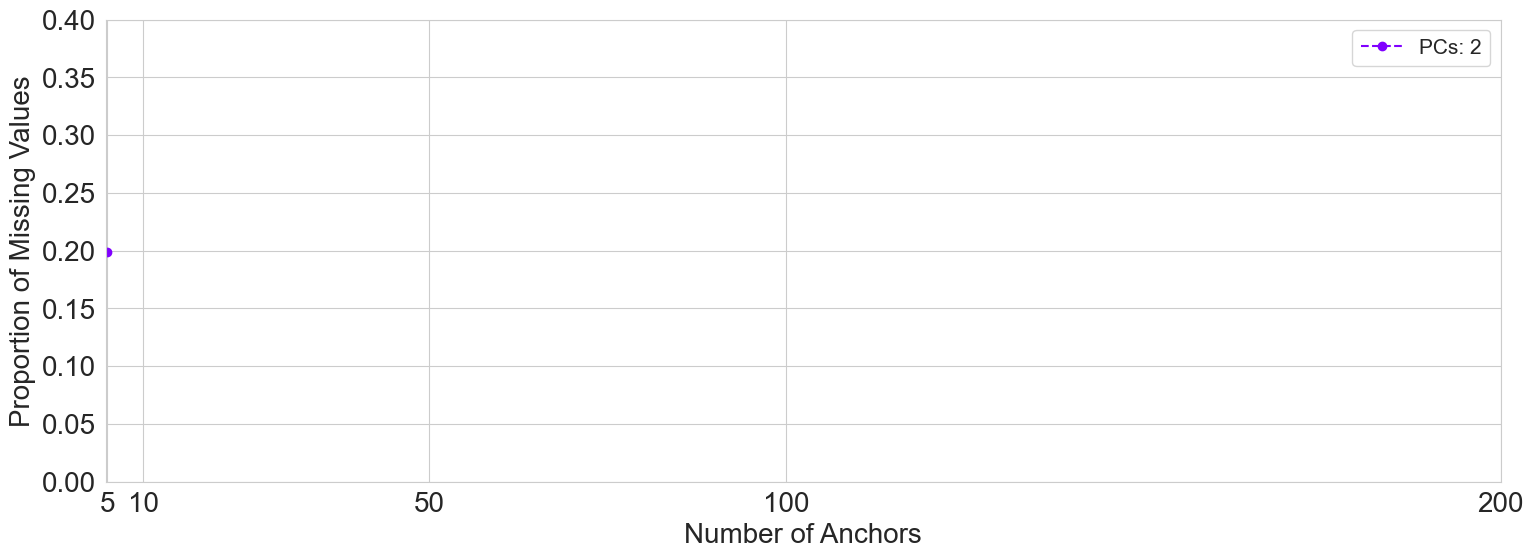

In [ ]:
# x-axis: n_anchors, y-axis: fdr_conf1, group by: n_pc
unique_n_pc = df['n_pcs'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_pc)))

plt.figure(figsize=(18, 6))
plt.ylim(0,0.4)

# Plot each line separately for each unique value in 'n_pc'
for i, n_pc in enumerate(unique_n_pc):
    subset_df = df[df['n_pcs'] == n_pc]
    mean_values = subset_df.groupby('n_anchors')['prop_nan_after'].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'PCs: {int(n_pc)}' if n_pc>0 else "Without ESM", color=colors[i])

plt.xlabel('Number of Anchors', fontsize=20)
plt.xticks([5,10,50,100,200], fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Proportion of Missing Values', fontsize=20)
plt.legend(fontsize=15)

plt.show()

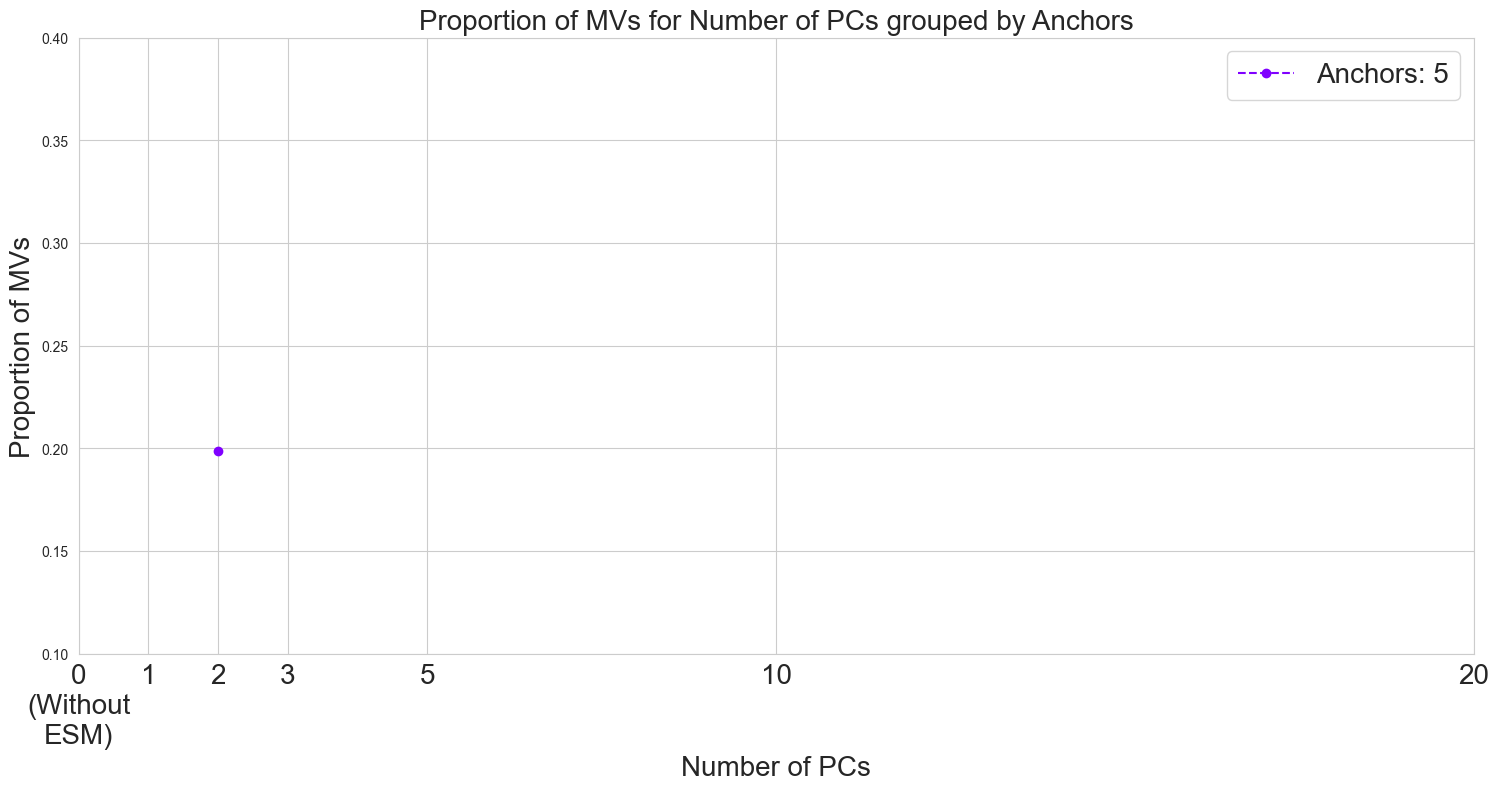

In [ ]:
# x-axis: n_pc, y-axis: fdr_conf1, group by: n_anchors
unique_n_anchors = df['n_anchors'].unique()

colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_anchors)))

plt.figure(figsize=(18, 8))
plt.ylim(0.1,0.4)


# Plot each line separately for each unique value in 'n_pc'
for i, n_anchor in enumerate(unique_n_anchors):
    subset_df = df[df['n_anchors'] == n_anchor]
    mean_values = subset_df.groupby('n_pcs')['prop_nan_after'].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'Anchors: {int(n_anchor)}', color=colors[i])

plt.xlabel('Number of PCs', fontsize=20)
plt.xticks([0,1,2,3,5,10,20], ['0\n(Without\nESM)',1,2,3,5,10,20], fontsize=20) # ,2,5,10
plt.ylabel('Proportion of MVs', fontsize=20)
plt.title('Proportion of MVs for Number of PCs grouped by Anchors', fontsize=20)
plt.legend(fontsize=20)

plt.show()

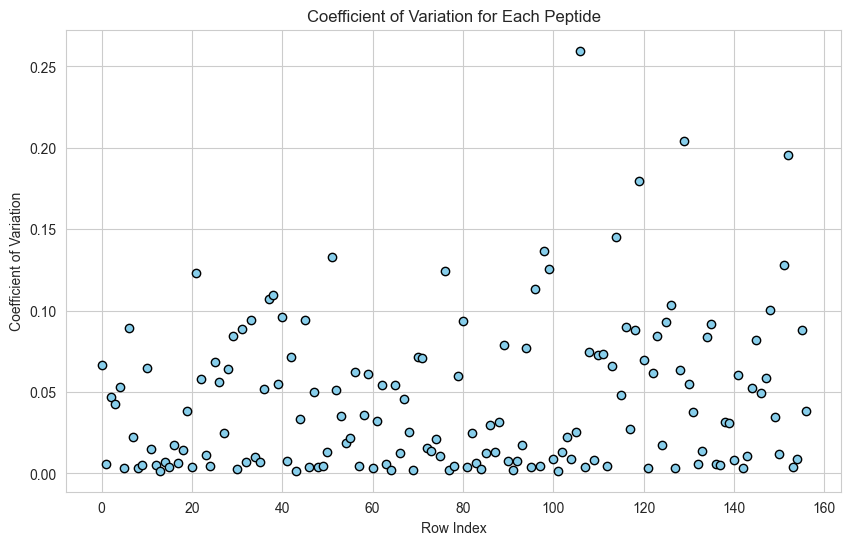

In [ ]:
# Log2 before CV calculation
expression_fill_log2 = np.log2(expression_fill)  

# Calculate the coefficient of variation for each row
cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))

# Create a dot plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=np.arange(len(cv_values)), y=cv_values, color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel('Row Index')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Coefficient of Variation for Each Peptide')

plt.show()

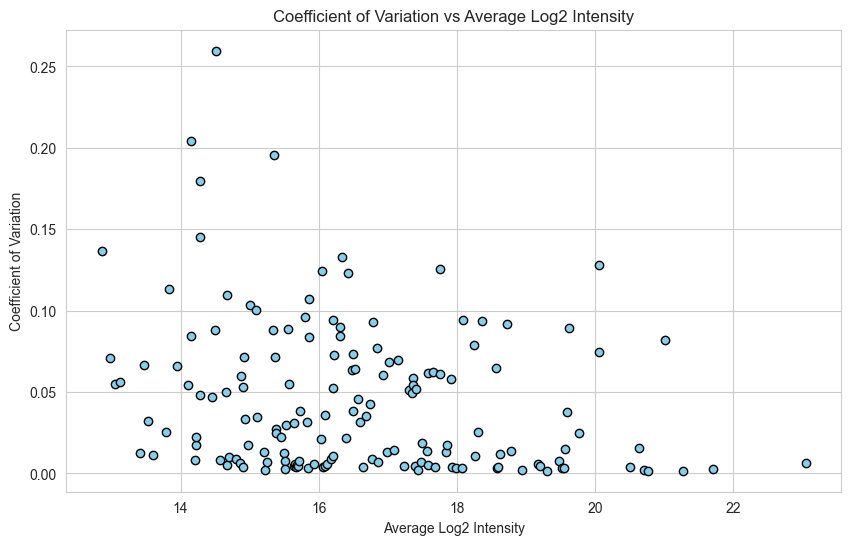

In [ ]:
# Log2 before CV calculation
expression_fill_log2 = np.log2(expression_fill)     

# Average Log2 intensity per row/peptide
log2_mean_per_peptide = expression_fill_log2.mean(axis=1)

# Calculate the coefficient of variation for each row
cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))

cv_vs_log2 = pd.concat([log2_mean_per_peptide, cv_values], axis=1)

cv_vs_log2.columns = ['Log2', 'CV']

# Sort according to log2 intensity
cv_vs_log2 = cv_vs_log2.sort_values(by='Log2')

# Create a dot plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=cv_vs_log2['Log2'], y=cv_vs_log2['CV'], color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel('Average Log2 Intensity')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Coefficient of Variation vs Average Log2 Intensity')

plt.show()

Let's compute the coefficient of variance for each peptide and plot it with the mean.

In [ ]:
expression_cv_features = expression_features[['PrecursorID', 'Intensities']].copy()
expression_cv_features['Intensities'] = np.log2(expression_cv_features['Intensities'] + 1)

expression_cv_features = expression_cv_features.groupby('PrecursorID').agg(['mean', 'std'])
expression_cv_features['CV'] = expression_cv_features['Intensities']['std'] / expression_cv_features['Intensities']['mean']
expression_cv_features['CV2'] = expression_cv_features['CV'] ** 2

In [ ]:
n = 10_000
random_indices = np.random.choice(range(len(expression_cv_features)), size=n, replace=False)

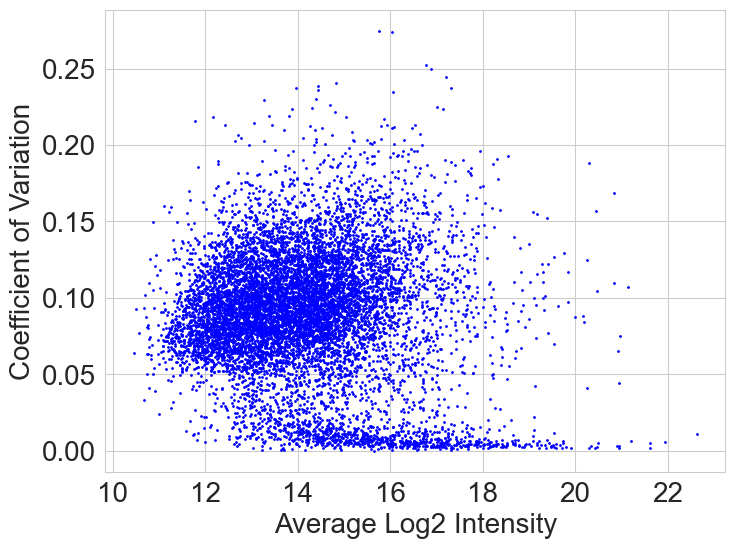

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(expression_cv_features['Intensities']['mean'].iloc[random_indices], expression_cv_features['CV'].iloc[random_indices], s=1, color='blue')
ax.set_xlabel('Average Log2 Intensity', fontsize=20)
#ax.set_ylabel('CV²', fontsize=20)
ax.set_ylabel('Coefficient of Variation', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# ax.set_title('Log Expression | Intensity: CV² vs Mean')
ax.grid(True)
ax.set_axisbelow(True)